In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools
import os
import sys
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import time
from datetime import datetime

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Configurar pandas para mostrar todas las filas y columnas sin cortes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

sys.path.append(os.getcwd())

script_dir = os.getcwd()
print(f"script_dir: {script_dir}")

# Configurar la fuente del texto
mpl.rc('font', family='serif', serif='cmr10', size=12)
plt.rcParams['axes.unicode_minus'] = False

# Configurar la fuente de MathText para que use Computer Modern
mpl.rcParams['mathtext.fontset'] = 'cm'  # Usa las fuentes de Computer Modern para las ecuaciones
mpl.rcParams['mathtext.rm'] = 'serif'    # Usa 'serif' para el modo matemático normal
mpl.rcParams['mathtext.it'] = 'serif:italic'  # Itálica para símbolos matemáticos
mpl.rcParams['mathtext.bf'] = 'serif:bold'    # Negrita para símbolos matemáticos

script_dir: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images


In [2]:
import pandas as pd
import numpy as np
import os
import sys

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

sys.path.append(os.getcwd())

script_dir = os.getcwd()
print(f"script_dir: {script_dir}")

Svc = 'STK'
placement_optimal = 'bus3007'
# Cargar los datos del archivo CSV en un DataFrame
df_h_1to8760 = pd.read_csv(f'Data_BESS_Size_Options/df_{Svc}_h_1to8760.csv')
df_h_1to8760 = df_h_1to8760[df_h_1to8760['BatteryNode'] == f'{placement_optimal}']

df_h_1to8760['f5'] = 100 - df_h_1to8760['f5']
print(f"df_h_1to8760: \n{df_h_1to8760}\n")


script_dir: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images
df_h_1to8760: 
     Svc BatteryNode  P_BESS  E_BESS  Total_Investment  Annual_Revenue         f1        f2        f3        f4  s_m_PS  s_m_PS_BESS         f5     f5_PS  threshold_peak_demand     P_CB_max       p_1       p_2       p_3        p_4       p_5       Time
528  STK     bus3007     250    1000          455850.0    40159.998223  13.003329  1.822764  0.188520  0.007523    4310         2327  46.009281  0.360677                   1500  2361.604574  7.118721  5.871005  2.319635  84.463470  0.227169  33.885756
566  STK     bus3007     500    1000          523000.0    49261.634692  12.054679  2.547299  0.402548  0.041489    4310         1510  64.965197  0.474700                   1500  2361.604465  2.716895  7.650685  1.309361  86.261416  2.061644  28.249364
604  STK     bus3007    1000    1000          561900.0    48559.217428  13.300216  2.624051  0.457991  0.045064    4310

df_BESS_id: 
     id  E_BESS  P_BESS
528   1    1000     250
566   2    1000     500
604   3    1000    1000
642   4    2000     500
680   5    2000    1000
718   6    2000    2000
756   7    3000     750
794   8    3000    1500
832   9    3000    3000

df_f1: 
     id    f1
832   9  13.4
718   6  13.4
604   3  13.3
528   1  13.0
642   4  12.7
756   7  12.5
794   8  12.3
680   5  12.2
566   2  12.1

df_f2: 
     id     f2
604   3  2.624
566   2  2.547
680   5  2.393
718   6  2.393
794   8  2.297
832   9  2.297
528   1  1.823
642   4  1.776
756   7  1.737



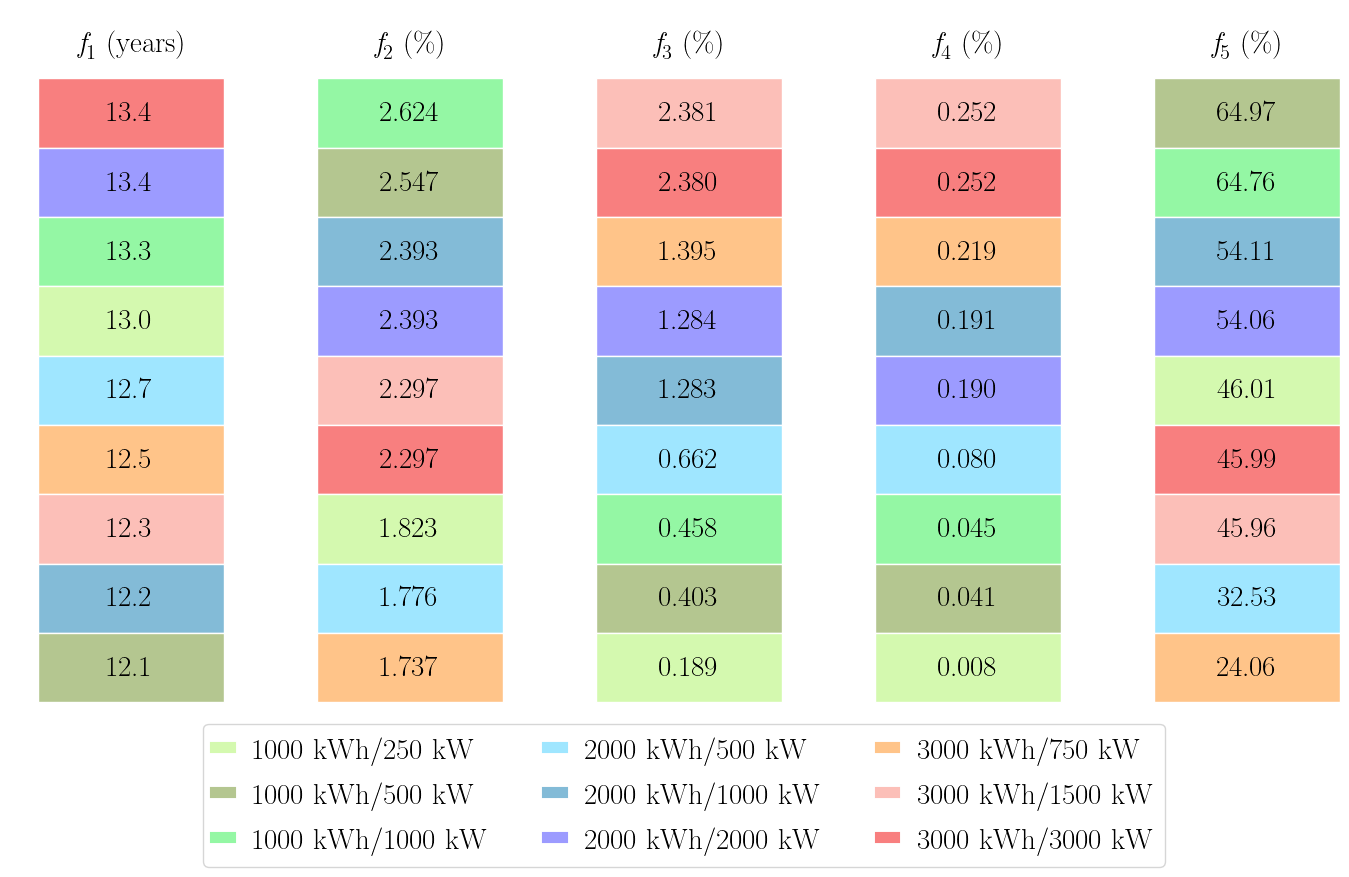

Gráfico PDF guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\STK_Fig_15_BESS_Option_Sizes\STK_Fig_15_BESS_Option_Sizesbus30074897to5064_20260428_110814.pdf
Existe PDF?: True
Gráfico SVG guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\STK_Fig_15_BESS_Option_Sizes\STK_Fig_15_BESS_Option_Sizesbus30074897to5064_20260428_110814.svg
Existe SVG?: True


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

e_alpha = 0.5
e_fontsize = 21 

primary_colors = {
    1: '#abf561', 2: '#6b8e23', 3: '#2af04b', 4: '#40cfff', 
    5: '#0979b0', 6: '#3b38ff', 7: '#ff8a14', 8: '#fa8072', 9: '#f30000'
}

# Asegurarse de que matplotlib use LaTeX
plt.rcParams['text.usetex'] = True  # Activar uso de LaTeX en matplotlib

# Crear una copia de los datos relevantes para el Parallel Plot
df_sizing = df_h_1to8760[['P_BESS', 'E_BESS', 'f1', 'f2', 'f3', 'f4','f5']].copy()
df_sizing['id'] = np.arange(1, 10)  # Genera un array de números del 1 al 9
df_BESS_id = df_sizing[['id', 'E_BESS', 'P_BESS']].copy()
print(f"df_BESS_id: \n{df_BESS_id}\n")

# Modificar las columnas f1, f2, f3, f4 para agregar las letras correspondientes
#df_sizing['f1'] = df_sizing['f1'].apply(lambda x: f"{(x/1000):.1f}")
# df_sizing['f1'] = (df_sizing['f1'] / 1000).apply(lambda x: f"{x:.1f}")
# df_sizing['f1'] = df_sizing['f1'].apply(lambda x: str(x).strip())  # Eliminar espacios
# df_sizing['f1'] = pd.to_numeric(df_sizing['f1'], errors='coerce')  # Convertir a numérico


#df_sizing['f1'] = df_sizing['f1'].apply(lambda x: f"{x:.1f}")  # Agregar valores a la columna f2
df_sizing['f2'] = df_sizing['f2'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f2
df_sizing['f3'] = df_sizing['f3'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f3
df_sizing['f4'] = df_sizing['f4'].apply(lambda x: f"{x:.3f}")  # Agregar valores a la columna f4
df_sizing['f5'] = df_sizing['f5'].apply(lambda x: f"{x:.2f}")  # Agregar valores a la columna f4

# Ahora se actualiza df_f1, df_f2, df_f3, df_f4
df_f1 = df_sizing[['id', 'f1']].astype({'f1': 'float'}).sort_values(by='f1', ascending=False)
df_f2 = df_sizing[['id', 'f2']].astype({'f2': 'float'}).sort_values(by='f2', ascending=False)
df_f3 = df_sizing[['id', 'f3']].astype({'f3': 'float'}).sort_values(by='f3', ascending=False)
df_f4 = df_sizing[['id', 'f4']].astype({'f4': 'float'}).sort_values(by='f4', ascending=False)
df_f5 = df_sizing[['id', 'f5']].astype({'f5': 'float'}).sort_values(by='f5', ascending=False)

# Convertir a texto después de ordenar, solo para mostrar en la tabla
df_f1['f1'] = df_f1['f1'].apply(lambda x: f"{x:.1f}")
df_f2['f2'] = df_f2['f2'].apply(lambda x: f"{x:.3f}")
df_f3['f3'] = df_f3['f3'].apply(lambda x: f"{x:.3f}")
df_f4['f4'] = df_f4['f4'].apply(lambda x: f"{x:.3f}")
df_f5['f5'] = df_f5['f5'].apply(lambda x: f"{x:.2f}")

print(f"df_f1: \n{df_f1}\n")
print(f"df_f2: \n{df_f2}\n")

# Definir los encabezados con formato LaTeX
col_headers_1 = ['ID', r"$\textit{f}_1$ (\%)", r"$\textit{f}_2$ (\%)", r"$\textit{f}_3$ (\%)", r"$\textit{f}_4$ (\%)"]

# Nombres personalizados para la segunda columna de cada DataFrame
col_headers_custom = [
    [r"$\textit{f}_1$ (years)"],  # Para df_P_BESS
    [r"$\textit{f}_2$ (\%)"],  # Para df_f1
    [r"$\textit{f}_3$ (\%)"],     # Para df_f2
    [r"$\textit{f}_4$ (\%)"],     # Para df_f3
    [r"$\textit{f}_5$ (\%)"]      # Para df_f4
]

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 9))

# Dibujar las tablas lado a lado con sus respectivos colores de fondo
tables = [df_f1, df_f2, df_f3, df_f4, df_f5]
x_offset = 0.5  # Para desplazar las tablas hacia la derecha

# Dibujar las tablas lado a lado con flechas al costado izquierdo
tables = [df_f1, df_f2, df_f3, df_f4, df_f5]
x_offset = 0  # Para desplazar las tablas hacia la derecha
line_offsets = [-0.5, -0.3, -0.1, 0.1, 0.2]  # Posiciones horizontales ajustadas para las flechas

# Iterar sobre los DataFrames y crear las tablas
for idx, df in enumerate(tables):

    # Dibujar flecha al costado izquierdo de cada DataFrame
    line_x = line_offsets[idx]
    line_y = [0, 1]  # Altura de la línea (de abajo hacia arriba)
    arrow_head_y = 1.05  # Posición de la punta de la flecha

    # # Línea vertical y flecha
    # ax.plot([line_x, line_x], line_y, color='black', lw=2)
    # ax.annotate('', xy=(line_x, arrow_head_y), xytext=(line_x, 1),
    #             arrowprops=dict(facecolor='black', arrowstyle='wedge,tail_width=0.5', lw=0))


    # Crear una copia temporal del DataFrame y eliminar 'id'
    df_temp = df.drop(columns=['id'])  # Solo eliminamos 'id' de la copia

    # Asignar encabezados personalizados para la segunda columna en cada DataFrame
    col_headers = col_headers_custom[idx]  # Solo usar el encabezado personalizado para cada DataFrame

    # Crear la tabla con los encabezados correspondientes
    table = ax.table(cellText=df_temp.values,  # Usar la copia sin 'id'
                    colLabels=col_headers,  # Encabezado personalizado sin 'ID'
                    loc='center', 
                    cellLoc='center', 
                    colLoc='center', 
                    bbox=[x_offset+ 0.03, 0, 0.20, 1])

    # Ajustar el tamaño de la fuente en las celdas y los encabezados
    for (i, j), cell in table.get_celld().items():
        cell.set_fontsize(e_fontsize)  # Ajustar tamaño de la fuente para todas las celdas y encabezados
        if i == 0:  # Las celdas del encabezado
            cell.set_facecolor('white')  # Fondo gris claro
            cell.set_edgecolor('white')  # Bordes blancos para los encabezados
        else:
            cell.set_edgecolor('white')  # Bordes blancos para las celdas restantes
    
    # Asignar los colores de fondo a las filas (solo para las filas de datos, no encabezado)
    for i, row in enumerate(df.values):  # Aún usamos el DataFrame original para asignar colores
        id_value = row[0]  # El valor del 'id' en la primera columna
        color = primary_colors[id_value]  # Obtener el color correspondiente al id
        color_rgba = mcolors.to_rgba(color, alpha=e_alpha)  # Convertir a color con alpha
        
        for j in range(1, df.shape[1]):  # Para cada celda (omitimos la columna 'id')
            cell = table[(i+1, j-1)]  # Ajustamos índices para reflejar el DataFrame modificado
            cell.set_facecolor(color_rgba)
            cell.set_edgecolor('white')  # Bordes blancos
    
    # Ajustar la posición de la tabla
    x_offset += 0.3  # Desplazar la siguiente tabla para que se muestre a la derecha

ax.axis('off')

# Guardar el gráfico como archivo PDF
output_path = 'DataFrames_colored.pdf'
plt.savefig(output_path, bbox_inches='tight', dpi=300)

###########

# Colores primarios asignados manualmente

primary_colors = ['#abf561', '#6b8e23', '#2af04b', 
                  '#40cfff', '#0979b0', '#3b38ff', 
                  '#ff8a14', '#fa8072', '#f30000']

df_BESS_id['Label'] = df_h_1to8760.apply(
    lambda row: f"{row['E_BESS']} kWh/{row['P_BESS']} kW",
    axis=1
)

unique_labels = df_BESS_id['Label'].unique()
color_map = dict(zip(unique_labels, primary_colors))

# Crear una leyenda agrupada correctamente
handles = [
    plt.Line2D([], [], color=color_map[label], lw=8, label=label, alpha=e_alpha)
    for label in unique_labels
]

# Posicionar la leyenda debajo del gráfico
plt.legend(
    handles=handles,
    bbox_to_anchor=(0.725, -0.01),  # Posición abajo
    loc='upper center',
    ncol=3,  # Número de columnas en la leyenda
    frameon=True,  # Sin borde en la leyenda
    fontsize=e_fontsize,
    handlelength=0.5,  # Longitud de las líneas en la leyenda
    handleheight=1  # Altura de los marcadores en la leyenda
    
)

######## Save image
output_dir = os.path.join(script_dir, f'{Svc}_Fig_15_BESS_Option_Sizes')
os.makedirs(output_dir, exist_ok=True)

now = datetime.now()
fecha_hora = now.strftime("%Y%m%d_%H%M%S")

primera_hora = 4897   # 24 de julio | 00 to 01
ultima_hora  = 5064   # 30 de julio | 23 to 24
P_BESS = 1000
E_BESS = 250

nombre_base = (
    f'{Svc}_Fig_15_BESS_Option_Sizes'
    f'{placement_optimal}'
    f'{primera_hora}to{ultima_hora}_'
    f'{fecha_hora}'
)

# Paths
output_path_pdf = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.pdf')
)

output_path_svg = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.svg')
)

# Save exactly the same figure in both formats
fig.savefig(output_path_pdf, bbox_inches='tight', dpi=300)
fig.savefig(output_path_svg, bbox_inches='tight', dpi=300)

plt.show()

print(f"Gráfico PDF guardado en: {output_path_pdf}")
print(f"Existe PDF?: {os.path.exists(output_path_pdf)}")

print(f"Gráfico SVG guardado en: {output_path_svg}")
print(f"Existe SVG?: {os.path.exists(output_path_svg)}")